In [10]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.cluster.vq import whiten
from statsmodels.tsa.stattools import adfuller
import lzma
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
from bin.criterions import *
import zlib
np.seterr(all = 'ignore')

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [11]:
def generate_time_series(length, type='predictable', sigma=0.1):
    length = int(length)
    if type == 'random walk':
        return np.cumsum(np.random.uniform(-sigma**2, sigma**2, size=length))
    elif type == 'white noise':
        return np.random.uniform(-sigma**2, sigma**2, size=length)  # White noise
    elif type == 'periodic':
        return np.sin(np.linspace(0, 4 * np.pi, length)) + np.random.normal(0, sigma, size=length)  # Sinusoidal wave
    elif type == 'linear':
        return np.linspace(0, 1, length) + np.random.normal(0, sigma, size=length)  # Linear trend
    elif type == 'quadratic':
        return np.linspace(0, 1, length) ** 2 + np.random.normal(0, sigma, size=length)  # Quadratic trend

In [14]:
def cluster_quantization(series, n_clusters):
    whitened = whiten(series)
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(whitened.reshape(-1, 1))
    return kmeans.cluster_centers_[kmeans.labels_]


def compress_data_lzw(data):
    return lzma.compress(data)


def calculate_compression_ratio(original, compressed):
    return len(original) / len(compressed)


def check_stationarity_and_difference(series):
    """
    Check if a time series is stationary using the Augmented Dickey-Fuller test.
    If not stationary, apply first-order differencing.
    
    :param series: pandas Series object representing the time series.
    :return: stationary_series is the (differenced) series.
    """
    # Perform the ADF test
    adf_result = adfuller(series)
    p_value = adf_result[1]
    is_stationary = p_value < 0.05
    
    if is_stationary:
        return series
    else:
        # Perform first-order differencing
        differenced_series = pd.Series(series).diff().dropna().to_numpy()
        return differenced_series

def process_time_series(lengths, types):
    compression_ratios = {t: [] for t in types}
    
    for length in lengths:
        for t in types:
            ar_ratio = []
            for i in range(10):
                series = generate_time_series(length, type=t)
                series = check_stationarity_and_difference(series)
                n_clusters = max(1, length // 10)  # Ensure at least 1 cluster
                quantized_series = cluster_quantization(series, int(n_clusters))
                original_data = quantized_series.tobytes()
                compressed_data = compress_data_lzw(original_data)
                compression_ratio = calculate_compression_ratio(original_data, compressed_data)
                ar_ratio.append(compression_ratio)
            compression_ratios[t].append(np.mean(ar_ratio))
    
    return compression_ratios


def plot_results(lengths, compression_ratios):
    for t, ratios in compression_ratios.items():
        plt.plot(lengths, ratios, label=t)
    plt.xlabel('Length of Time Series')
    plt.ylabel('Average Compression Ratio')
    plt.legend()
    plt.show()



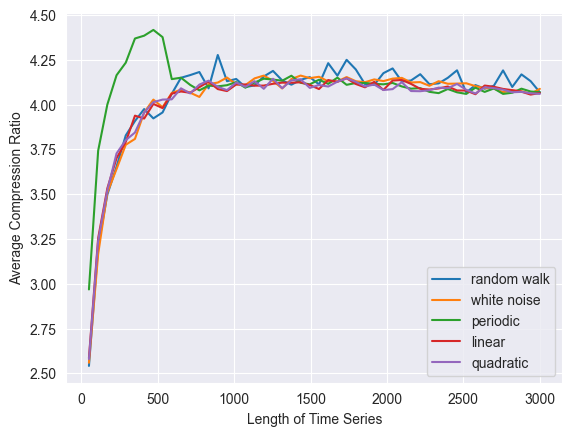

In [15]:
lengths = np.linspace(50, 3000, 50)
types = ['random walk', 'white noise', 'periodic', 'linear', 'quadratic']

compression_ratios = process_time_series(lengths, types)
plot_results(lengths, compression_ratios)

In [57]:
def process_time_series_by_length(lengths, types, sigma = 0.3):
    compression_ratios = {t: [] for t in types}
    
    for length in lengths:
        for t in types:
            ar_ratio = []
            for i in range(10):
                series = generate_time_series(length, type=t, sigma=sigma)
                n_clusters = max(1, length // 10)  # Ensure at least 1 cluster
                quantized_series = cluster_quantization(series, int(n_clusters))
                original_data = quantized_series.tobytes()
                compressed_data = compress_data_lzw(original_data)
                compression_ratio = calculate_compression_ratio(original_data, compressed_data)
                ar_ratio.append(compression_ratio)
            compression_ratios[t].append(np.mean(ar_ratio))
    
    return compression_ratios

def process_time_series_by_noise(ar_sigma, types, length = 300):
    compression_ratios = {t: [] for t in types}
    
    for sigma in ar_sigma:
        for t in types:
            ar_ratio = []
            for i in range(10):
                series = generate_time_series(length, type=t, sigma=sigma)
                n_clusters = max(1, length // 10)  # Ensure at least 1 cluster
                quantized_series = cluster_quantization(series, int(n_clusters))
                original_data = quantized_series.tobytes()
                compressed_data = compress_data_lzw(original_data)
                compression_ratio = calculate_compression_ratio(original_data, compressed_data)
                ar_ratio.append(compression_ratio)
            compression_ratios[t].append(np.mean(ar_ratio))
    
    return compression_ratios

In [60]:
def plot_results_by_length(lengths, compression_ratios_by_length):
    for t, ratios in compression_ratios_by_length.items():
        plt.plot(lengths, ratios, label=t)
    plt.xlabel('Length of Time Series')
    plt.ylabel('Average Compression Ratio')
    plt.legend()
    plt.title('Compression Ratio vs Length of Time Series')
    plt.show()
    
def plot_results_by_noise(noise_levels, compression_ratios_by_noise, length):
    for t, ratios in compression_ratios_by_noise.items():
        plt.plot(noise_levels, ratios, label=t)
    plt.xlabel('Noise Level')
    plt.ylabel('Average Compression Ratio')
    plt.legend()
    plt.title(f'Compression Ratio vs Noise Level for Length {length}')
    plt.show()

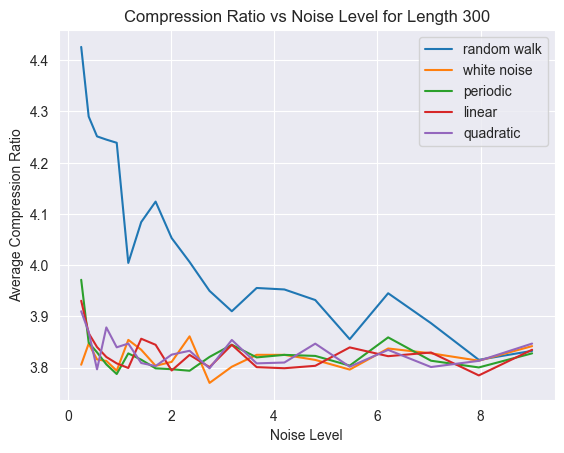

In [61]:
lengths = np.linspace(50, 3000, 50)
types = ['random walk', 'white noise', 'periodic', 'linear', 'quadratic']
noise_lvl = np.logspace(0.1, 1, 20)-1
#compression_ratios_by_length = process_time_series_by_length(lengths, types)

compression_ratios_by_noise = process_time_series_by_noise(noise_lvl, types)

#plot_results_by_length(lengths, compression_ratios_by_length)

plot_results_by_noise(noise_lvl, compression_ratios_by_noise, 300)